# DSS Availability - Monthly Progression

Author: Erick Chauke

Date: May 2026

This notebook turns the monthly availability workbook into one slide-ready chart: each service's monthly availability from April to the latest month, with year-to-date shown alongside. Per-service targets differ and are deliberately left off the chart. It is built section by section, run in VS Code one cell at a time.

## Setup and config

Everything downstream reads from the single config cell below. To point this notebook at a different workbook, change only that cell and run all. The cell after it loads the libraries and resolves the paths.

In [1]:
# CONFIG - the only cell you edit to point at a different dataset
DATA_FILE = "data/Feedback 1/availability 1.xlsx"   # source workbook (gitignored)
YEAR_SHEET = None                       # fiscal-year sheet to chart; None = latest sheet
OUTPUT_DIR = "outputs"                  # where the slide images are saved
ROLLING_MONTHS = 12                     # how many trailing months the tile view shows
Y_AXIS_PAD = 0.5                        # percentage points of headroom for the columns view


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH = Path(DATA_FILE)
OUT_PATH = Path(OUTPUT_DIR)
OUT_PATH.mkdir(exist_ok=True)
STEM = DATA_PATH.stem

print("pandas", pd.__version__)
print("data file:", DATA_PATH, "| exists:", DATA_PATH.exists())
print("output dir:", OUT_PATH.resolve())


pandas 2.2.3
data file: data\Feedback 1\availability 1.xlsx | exists: True
output dir: D:\2026\Eskom\DSS availability\availability-visualiser\outputs


## Data ingestion and inspection

The workbook holds one sheet per fiscal year plus a couple of helper sheets. This section discovers the fiscal-year sheets, selects the one to chart (the config value, or the latest year by default), and reads it with no assumed header so we can locate the summary and history blocks ourselves. The raw frame is printed so the real layout is confirmed before any parsing.

In [3]:
import re

xl = pd.ExcelFile(DATA_PATH)

def fiscal_year_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None

year_sheets = sorted(
    [s for s in xl.sheet_names if fiscal_year_start(s) is not None],
    key=fiscal_year_start,
)
sheet = YEAR_SHEET or year_sheets[-1]

print("all sheets   :", xl.sheet_names)
print("year sheets  :", year_sheets)
print("charting     :", sheet)

raw = pd.read_excel(DATA_PATH, sheet_name=sheet, header=None, na_values=["NULL", "None"])
print("raw shape    :", raw.shape)
print("current month:", raw.iloc[0, 1])
raw


all sheets   : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027', 'Sheet1']
year sheets  : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027']
charting     : 2026-2027
raw shape    : (26, 13)
current month: June


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Month,June,NaN,NaN,NaN,NaN,<--- Change this to get a report for the speci...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Service,Availability,YTD,Target,Comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Powi,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Systemops,1,0.99998,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Themis,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,TEMSE HIS,0.99993,0.99997,0.99,NaN,"""http://ncssnagios.eskom.co.za/trends.html""",NaN,NaN,NaN,""" with user/passwod: nagiosadmin""",NaN,NaN
6,NaN,TEMSE NCC,0.99996,0.999957,0.99992,NaN,"""http://systemops.eskom.co.za/temse/downtime/""",NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,TEMSE SCC,0.9995,0.999367,0.9992,NaN,"""SCC availability link on http://encweb1e06"" -...",NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Powi,Powi YTD,Systemops,Systemops YTD,Themis,Themis YTD,TEMSE HIS,HIS YTD,TEMSE NCC,NCC YTD,TEMSE SCC,SCC YTD


## Cleaning and parsing

The history block sits below the summary block in each sheet. We anchor on the April and March month labels to locate it without hard-coding row numbers, pair each service column with the YTD column immediately to its right, and reshape into a tidy long table with one row per service and month. Availability is stored as a fraction in the workbook, so we scale it to a percentage. Numeric coercion is logged. Months with no reading yet (the future months of the current year) are dropped from the monthly series, while the YTD carried in the workbook gives each service its year-to-date figure.

In [4]:
# Locate the history block by anchoring on the April and March month labels
month_labels = raw[0].astype(str).str.strip()
april_idx = month_labels[month_labels == "April"].index[0]
march_idx = month_labels[month_labels == "March"].index[0]
header = raw.iloc[april_idx - 1]

# Pair each service column with the YTD column immediately to its right
service_cols = {}
c = 1
while c < raw.shape[1] and pd.notna(header[c]):
    service_cols[str(header[c]).strip()] = (c, c + 1)
    c += 2

SERVICES = list(service_cols)
print("services:", SERVICES)

# Reshape the month rows into tidy long form, scaling fractions to percentages
hist = raw.iloc[april_idx:march_idx + 1]
months = hist[0].astype(str).str.strip().tolist()

records = []
lost = 0
for svc, (avail_c, ytd_c) in service_cols.items():
    avail = pd.to_numeric(hist[avail_c], errors="coerce")
    ytd = pd.to_numeric(hist[ytd_c], errors="coerce")
    lost += int((avail.isna() & hist[avail_c].notna()).sum())
    lost += int((ytd.isna() & hist[ytd_c].notna()).sum())
    for m, a, y in zip(months, avail, ytd):
        records.append({
            "service": svc,
            "month": m,
            "availability": a * 100 if pd.notna(a) else a,
            "ytd": y * 100 if pd.notna(y) else y,
        })

tidy = pd.DataFrame(records)
tidy["month"] = pd.Categorical(tidy["month"], categories=months, ordered=True)
print("values lost to coercion:", lost)

# Monthly series keeps only months with a real reading; YTD reference is the latest one
monthly = tidy.dropna(subset=["availability"]).copy()
filled_months = monthly["month"].cat.remove_unused_categories().cat.categories.tolist()
latest_month = filled_months[-1]
ytd_now = tidy[tidy["month"] == latest_month].set_index("service")["ytd"]

print("filled months:", filled_months)
print("latest month :", latest_month)
print()
print("current year to date by service:")
print(ytd_now.to_string())

# Per-service targets from the summary block, used for the target line
summary_labels = raw[1].astype(str).str.strip()
summary_hdr = summary_labels[summary_labels == "Service"].index[0]
targets = {}
r = summary_hdr + 1
while r < raw.shape[0] and pd.notna(raw.iloc[r, 1]) and str(raw.iloc[r, 1]).strip() not in ("", "nan"):
    svc_name = str(raw.iloc[r, 1]).strip()
    t = pd.to_numeric(raw.iloc[r, 4], errors="coerce")
    if pd.notna(t):
        targets[svc_name] = t * 100
    r += 1
    if r - summary_hdr > 8:
        break
print("targets:", targets)

monthly


services: ['Powi', 'Systemops', 'Themis', 'TEMSE HIS', 'TEMSE NCC', 'TEMSE SCC']
values lost to coercion: 0
filled months: ['April', 'May', 'June']
latest month : June

current year to date by service:
service
Powi         100.000000
Systemops     99.998000
Themis       100.000000
TEMSE HIS     99.997000
TEMSE NCC     99.995667
TEMSE SCC     99.936667
targets: {'Powi': 99.25, 'Systemops': 99.25, 'Themis': 99.25, 'TEMSE HIS': 99.0, 'TEMSE NCC': 99.992, 'TEMSE SCC': 99.92}


,service,month,availability,ytd
0,Powi,April,100.000,100.000000
1,Powi,May,100.000,100.000000
2,Powi,June,100.000,100.000000
12,Systemops,April,99.996,99.996000
13,Systemops,May,99.998,99.997000
14,Systemops,June,100.000,99.998000
24,Themis,April,100.000,100.000000
25,Themis,May,100.000,100.000000
26,Themis,June,100.000,100.000000
36,TEMSE HIS,April,99.998,99.998000


## Visualisation

One figure, an executive tile grid with a panel per service, sized for a single slide. Each tile shows a rolling twelve months so the trend is visible: a solid blue line for monthly availability and an orange dashed line for the year to date, on the tile's own vertical scale capped at 100 percent. A dotted line marks that service's target. Three markers carry the warnings: a month below target is a red triangle, the lowest month of the window is a red circle with a white centre, and where the lowest month is itself a breach the triangle is kept. Where the year to date sits below target the gap is shaded red, deeper the further below it runs. A vertical line marks the start of the new financial year in April. Tiles are ordered by the current month, lowest first. Everything is read from the workbook, so next month's file just works. The figure is saved to the outputs folder under the source file stem.

saved outputs\availability 1_monthly_availability.png


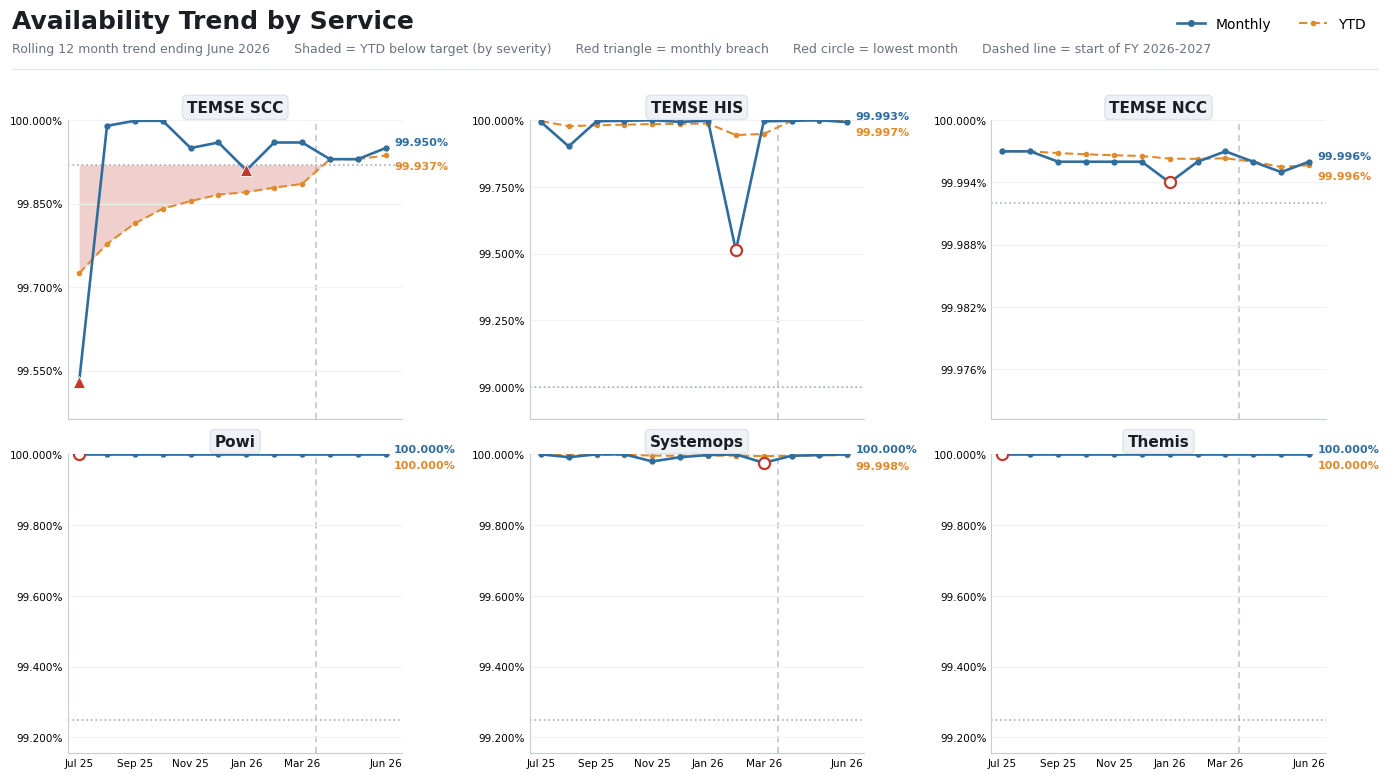

In [5]:
import re, math

MONTH_NUM = {"April": 4, "May": 5, "June": 6, "July": 7, "August": 8, "September": 9,
             "October": 10, "November": 11, "December": 12, "January": 1, "February": 2, "March": 3}


def fy_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None


def cal_year(fy_first, month):
    return fy_first if MONTH_NUM[month] >= 4 else fy_first + 1


# Stitch every fiscal-year sheet into one continuous monthly timeline
xl = pd.ExcelFile(DATA_PATH)
all_sheets = sorted([s for s in xl.sheet_names if fy_start(s) is not None], key=fy_start)
rows = []
for sh_name in all_sheets:
    rw = pd.read_excel(DATA_PATH, sheet_name=sh_name, header=None, na_values=["NULL", "None"])
    ml = rw[0].astype(str).str.strip()
    if not (ml == "April").any():
        continue
    ai = ml[ml == "April"].index[0]
    mi = ml[ml == "March"].index[0]
    hd = rw.iloc[ai - 1]
    sc, c = {}, 1
    while c < rw.shape[1] and pd.notna(hd[c]):
        sc[str(hd[c]).strip()] = (c, c + 1)
        c += 2
    block = rw.iloc[ai:mi + 1]
    mnames = block[0].astype(str).str.strip().tolist()
    fyf = fy_start(sh_name)
    for svc, (acol, ycol) in sc.items():
        av = pd.to_numeric(block[acol], errors="coerce")
        yt = pd.to_numeric(block[ycol], errors="coerce")
        for mm, a, y in zip(mnames, av, yt):
            rows.append(dict(service=svc, date=pd.Timestamp(cal_year(fyf, mm), MONTH_NUM[mm], 1),
                             availability=a * 100 if pd.notna(a) else None,
                             ytd=y * 100 if pd.notna(y) else None))
roll_df = pd.DataFrame(rows)

filled = roll_df.dropna(subset=["availability"])
latest_date = filled["date"].max()
window_months = list(pd.to_datetime(sorted([d for d in filled["date"].unique() if d <= latest_date])[-ROLLING_MONTHS:]))
current_sheet = sheet
fy_first = fy_start(current_sheet)
new_fy_april = pd.Timestamp(fy_first, 4, 1)
april_idx = next((i for i, d in enumerate(window_months) if d == new_fy_april), None)

data = {}
for svc in SERVICES:
    sd = roll_df[roll_df["service"] == svc].set_index("date")
    mv = [sd.loc[d, "availability"] if d in sd.index else None for d in window_months]
    yv = [sd.loc[d, "ytd"] if d in sd.index else None for d in window_months]
    cur = next((v for v in reversed(mv) if v is not None), None)
    ytdc = next((v for v in reversed(yv) if v is not None), None)
    clean = [v for v in mv if v is not None]
    low = min(clean); low_i = mv.index(low)
    data[svc] = dict(mv=mv, yv=yv, cur=cur, ytd=ytdc, low=low, low_i=low_i, target=targets.get(svc))

order = sorted(SERVICES, key=lambda s: data[s]["cur"])

MONTH_C = "#2f6d9e"
YTD_C = "#e08a2e"
RED = "#c0392b"
TARGET_C = "#9aa3af"
INK = "#1b1f24"
MUTED = "#6b7280"

n = len(window_months)
x = list(range(n))
xlabels = [d.strftime("%b %y") for d in window_months]
show = [i for i in range(0, n, 2) if (n - 1 - i) >= 2]
show.append(n - 1)

ncols = 3
nrows = math.ceil(len(SERVICES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7.8))
fig.patch.set_facecolor("white")
axes = axes.ravel()

for pos, (ax, svc) in enumerate(zip(axes, order)):
    d = data[svc]
    tgt = d["target"]
    row = pos // ncols

    if april_idx is not None:
        ax.axvline(april_idx - 0.5, color="#b9c2cc", linewidth=1.1, linestyle=(0, (4, 3)), zorder=1)
    if tgt is not None:
        ax.axhline(tgt, color=TARGET_C, linestyle=(0, (1, 2)), linewidth=1.1, zorder=2)
        shortfall = max([tgt - v for v in d["yv"] if v is not None and v < tgt] + [0])
        if shortfall > 0:
            ax.fill_between(x, d["yv"], tgt, where=[(v is not None and v < tgt) for v in d["yv"]],
                            interpolate=True, color=RED, alpha=min(0.30, 0.12 + shortfall * 0.6),
                            zorder=1.5, linewidth=0)

    ax.plot(x, d["yv"], color=YTD_C, linestyle=(0, (4, 2)), linewidth=1.5, marker="o", markersize=3, zorder=3)
    ax.plot(x, d["mv"], color=MONTH_C, linewidth=1.9, marker="o", markersize=3.5, zorder=4)

    for i in range(n):
        v = d["mv"][i]
        if v is not None and tgt is not None and v < tgt:
            ax.plot([i], [v], marker="^", color=RED, markersize=8, zorder=6,
                    markeredgecolor="white", markeredgewidth=0.6)
    if not (tgt is not None and d["low"] < tgt):
        ax.plot([d["low_i"]], [d["low"]], marker="o", markerfacecolor="white", markeredgecolor=RED,
                markeredgewidth=1.6, markersize=8, zorder=7)

    floor = min([v for v in d["mv"] + d["yv"] if v is not None] + ([tgt] if tgt else []))
    ymin = floor - ((100 - floor) * 0.10 + 0.02)
    if 100 - ymin < 0.010:
        ymin = 100 - 0.010
    ax.set_ylim(ymin, 100)
    ax.set_xlim(-0.4, n - 0.4)

    ax.annotate(f"{d['cur']:.3f}%", (x[-1], d["mv"][-1]), textcoords="offset points",
                xytext=(6, 4), fontsize=8, fontweight="bold", color=MONTH_C, va="center")
    ax.annotate(f"{d['ytd']:.3f}%", (x[-1], d["yv"][-1]), textcoords="offset points",
                xytext=(6, -8), fontsize=8, fontweight="bold", color=YTD_C, va="center")

    ax.set_title(svc, fontsize=11, fontweight="bold", color=INK,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="#eef1f5", edgecolor="#dfe4ea"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.3f}%"))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.tick_params(labelsize=7.5, length=0)
    ax.set_xticks([x[i] for i in show])
    if row == nrows - 1:
        ax.set_xticklabels([xlabels[i] for i in show], fontsize=7.5)
    else:
        ax.set_xticklabels([])
    ax.grid(axis="y", color="#eef1f5", linewidth=0.7, zorder=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#c8ccd1")
    ax.spines["bottom"].set_color("#c8ccd1")

for ax in axes[len(SERVICES):]:
    ax.set_visible(False)

# Header: title left, legend top-right on the same line, subtitle below, thin divider
handles = [
    plt.Line2D([], [], color=MONTH_C, marker="o", linewidth=1.9, markersize=4, label="Monthly"),
    plt.Line2D([], [], color=YTD_C, linestyle=(0, (4, 2)), marker="o", markersize=3, linewidth=1.5, label="YTD"),
]
fig.legend(handles=handles, loc="upper right", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.988, 0.998))
fig.text(0.012, 0.992, "Availability Trend by Service", ha="left", va="top",
         fontsize=18, fontweight="bold", color=INK)
fig.text(0.012, 0.95,
         f"Rolling {ROLLING_MONTHS} month trend ending {window_months[-1].strftime('%B %Y')}"
         f"      Shaded = YTD below target (by severity)      Red triangle = monthly breach"
         f"      Red circle = lowest month      Dashed line = start of FY {current_sheet}",
         ha="left", va="top", fontsize=9, color=MUTED)
_div = plt.Line2D([0.012, 0.988], [0.915, 0.915], color="#e4e8ec", linewidth=1.0)
_div.set_transform(fig.transFigure)
fig.add_artist(_div)
fig.tight_layout(rect=[0.0, 0.0, 1, 0.895])

fig_path = OUT_PATH / f"{STEM}_monthly_availability.png"
fig.savefig(fig_path, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path)
plt.show()


### What the tile view shows

The rolling twelve months give each service a real trend to read. The dotted line is the target, and the warnings are colour coded: a red triangle is a month that finished below target, a red circle with a white centre is the lowest month in the window, and a red shaded band shows any stretch where the year to date ran below target, darker the deeper the shortfall. TEMSE SCC opened the window below its 99.92 percent target, with red triangles on the worst months and a shaded year-to-date gap that closes as it recovers into the new financial year. TEMSE HIS took a sharp one-month dip that is flagged as its lowest month but never breached its 99.0 percent target. The steady services sit at the top of their tiles, comfortably clear of target. Ordering by the current month keeps whatever needs attention in the top left.

## Alternative view: grouped columns

A second take on the same data for comparison, so the chart style can be chosen on its merits. Services sit along the bottom; within each service a column is drawn for every month from April to the latest, the value is printed on each column because the services run so close together, and the red diamond marks the year to date. It reads cleanly for a few months and gets busier as the year fills out. This figure is saved to the outputs folder under its own name so it does not overwrite the panel view.

saved outputs\availability 1_monthly_availability_columns.png


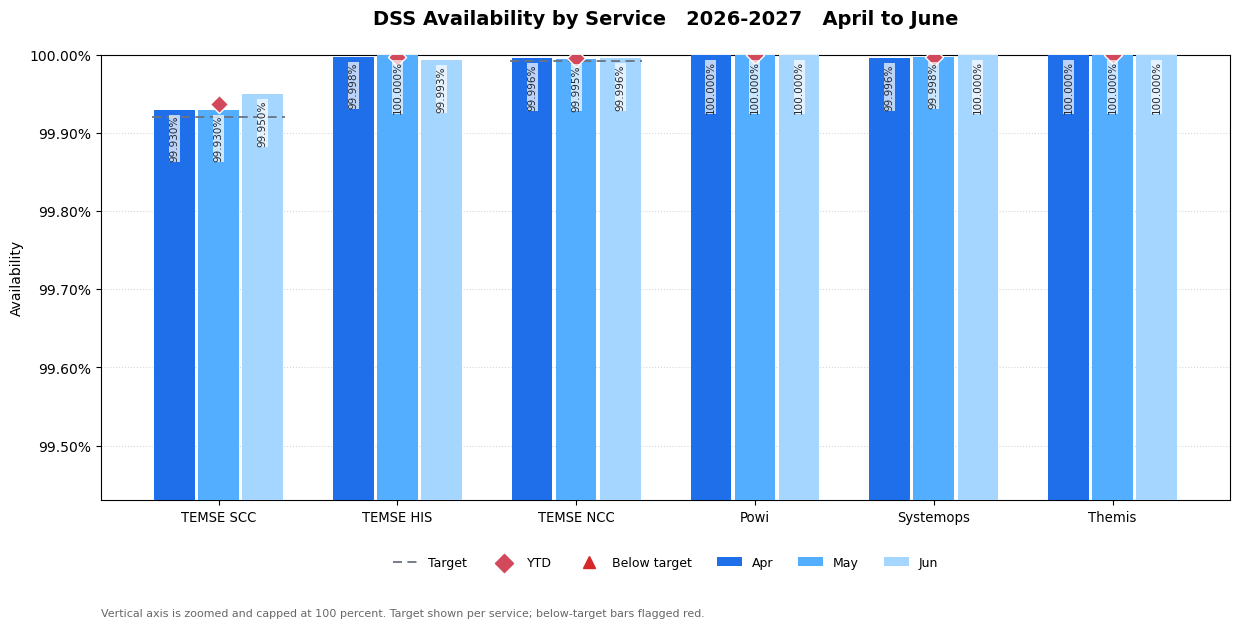

In [6]:
# Months in shades of blue, year to date as a red diamond. Services follow the tile order.
COL_MONTH_COLORS = ["#1f6feb", "#54aeff", "#a5d6ff"]
COL_YTD = "#d1495b"
COL_TARGET = "#6b7280"
COL_BELOW = "#d62728"
col_services = order  # same order as the tile view, most interesting first

all_vals = pd.concat([monthly["availability"], ytd_now]).dropna()
ymin = all_vals.min() - Y_AXIS_PAD
ymax = 100  # never above 100 percent

fig, ax = plt.subplots(figsize=(12.5, 6.8))
fig.patch.set_facecolor("white")
n = len(filled_months)
group_w = 0.74
bar_w = group_w / n
base = list(range(len(col_services)))
label_box = dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.4)

for j, m in enumerate(filled_months):
    vals = [monthly[(monthly["service"] == s) & (monthly["month"] == m)]["availability"].values[0]
            for s in col_services]
    offs = [b - group_w / 2 + bar_w / 2 + j * bar_w for b in base]
    ax.bar(offs, vals, width=bar_w * 0.92, color=COL_MONTH_COLORS[j % len(COL_MONTH_COLORS)],
           label=str(m)[:3], zorder=3)
    for xo, v, s in zip(offs, vals, col_services):
        ax.annotate(f"{v:.3f}%", (xo, v), textcoords="offset points", xytext=(0, -4),
                    ha="center", va="top", rotation=90, fontsize=7.5, color="#24292f",
                    bbox=label_box, zorder=5)
        # flag a bar that sits below its target
        tgt = targets.get(s)
        if tgt is not None and v < tgt:
            ax.plot([xo], [v], marker="^", color=COL_BELOW, markersize=8,
                    markeredgecolor="white", markeredgewidth=0.8, zorder=6)

# target as a short line across each service group
for b, s in zip(base, col_services):
    tgt = targets.get(s)
    if tgt is not None:
        ax.hlines(tgt, b - group_w / 2, b + group_w / 2, color=COL_TARGET,
                  linestyle=(0, (5, 3)), linewidth=1.3, zorder=4)
    ax.scatter([b], [ytd_now[s]], marker="D", s=85, color=COL_YTD, zorder=4,
               edgecolor="white", linewidth=1)

ax.plot([], [], color=COL_TARGET, linestyle=(0, (5, 3)), linewidth=1.3, label="Target")
ax.scatter([], [], marker="D", s=85, color=COL_YTD, label="YTD")
ax.plot([], [], marker="^", color=COL_BELOW, linestyle="", markersize=8, label="Below target")

ax.set_xticks(base)
ax.set_xticklabels(col_services, fontsize=9.5)
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), frameon=False, ncol=n + 3, fontsize=9)
ax.set_title(f"DSS Availability by Service   {sheet}   April to {latest_month}",
             fontsize=14, fontweight="bold", pad=22)
ax.set_ylabel("Availability")
ax.text(0.0, -0.26, "Vertical axis is zoomed and capped at 100 percent. Target shown per service; below-target bars flagged red.",
        transform=ax.transAxes, fontsize=8, color="#666666")
fig.tight_layout()
fig.subplots_adjust(top=0.88)

fig_path_columns = OUT_PATH / f"{STEM}_monthly_availability_columns.png"
fig.savefig(fig_path_columns, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path_columns)
plt.show()


### What the columns view shows

The same services as a straight comparison for the current financial year, with each service's target drawn across its group and any bar below target flagged in red. Right now every service is above target for April and May, so no bars are flagged, and the value printed on each bar carries the detail the heights cannot. This view answers how the services compare this month at a glance, while the tile view above carries the rolling trend. Both are capped at 100 percent.

## Executive summary table

A single-glance table of the current month, built to sit on the slide in place of the old spreadsheet table. Four counters across the top show how many services are on target, on watch or at risk. Each row gives the service, a status pill, this month's availability, the year to date with a direction arrow, the margin of the year to date over target, and the target itself. Rows are sorted by that margin, closest to target first, and the tightest row is boxed. A service is at risk if this month is below target, on watch if the month is fine but the year to date is still behind, and on target otherwise. The table is saved to the outputs folder as its own image.

saved outputs\availability 1_executive_summary.png


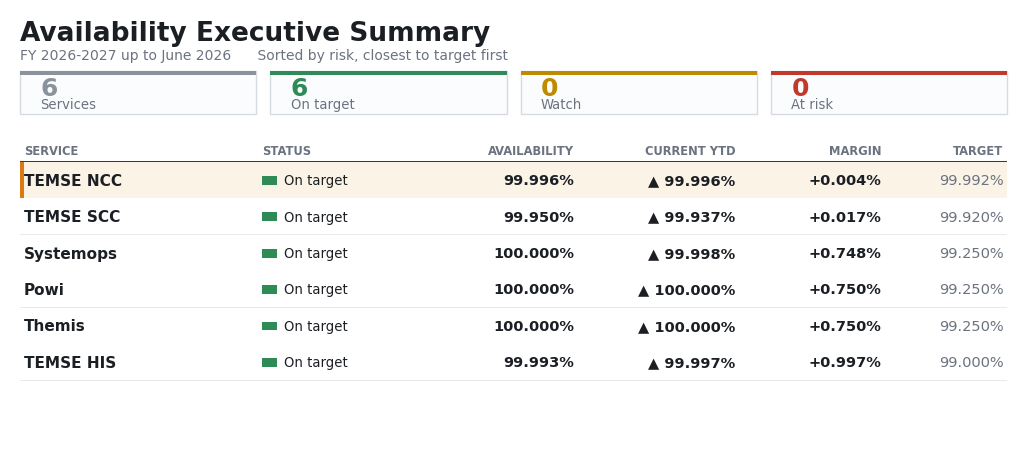

In [7]:
from matplotlib.patches import Rectangle

GREEN = "#2e8b57"
AMBER = "#c08a00"
REDP = "#c0392b"
GREY = "#8a929c"
INK = "#1b1f24"
MUTED = "#6b7280"
RULE_D = "#333a42"
RULE_L = "#e7e9ed"
HILITE = "#fbf3e6"
ACCENT = "#d97a12"

# One row per service from the current month and year to date
summary_rows = []
for svc in SERVICES:
    d = data[svc]
    tgt = d["target"]
    margin = d["ytd"] - tgt
    if d["cur"] < tgt:
        status = ("At risk", REDP)
    elif d["ytd"] < tgt:
        status = ("Watch", AMBER)
    else:
        status = ("On target", GREEN)
    summary_rows.append(dict(svc=svc, cur=d["cur"], ytd=d["ytd"], tgt=tgt, margin=margin, status=status))
summary_rows.sort(key=lambda r: r["margin"])

n_serv = len(summary_rows)
n_ok = sum(1 for r in summary_rows if r["status"][0] == "On target")
n_watch = sum(1 for r in summary_rows if r["status"][0] == "Watch")
n_risk = sum(1 for r in summary_rows if r["status"][0] == "At risk")

fig, ax = plt.subplots(figsize=(13, 5.7))
fig.patch.set_facecolor("white")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_autoscale_on(False)
ax.axis("off")

L, R = 0.010, 0.990


def rule(y, color, h=0.0013):
    ax.add_patch(Rectangle((L, y), R - L, h, facecolor=color, edgecolor="none", zorder=3))


ax.text(L, 0.975, "Availability Executive Summary", fontsize=19, fontweight="bold", color=INK, va="top")
ax.text(L, 0.912,
        f"FY {current_sheet} up to {window_months[-1].strftime('%B %Y')}      Sorted by risk, closest to target first",
        fontsize=10, color=MUTED, va="top")

# KPI cells: flat, straight edges, a thin colour rule on top
kpis = [("Services", n_serv, GREY), ("On target", n_ok, GREEN), ("Watch", n_watch, AMBER), ("At risk", n_risk, REDP)]
kw, gap, ky, kh = 0.2345, 0.0140, 0.760, 0.100
for j, (lab, val, fg) in enumerate(kpis):
    xk = L + j * (kw + gap)
    ax.add_patch(Rectangle((xk, ky), kw, kh, facecolor="#fbfcfd", edgecolor="#d6dbe1", linewidth=1.0, zorder=1))
    ax.add_patch(Rectangle((xk, ky + kh - 0.010), kw, 0.010, facecolor=fg, edgecolor="none", zorder=2))
    ax.text(xk + 0.020, ky + kh / 2 + 0.010, str(val), ha="left", va="center", fontsize=18, fontweight="bold", color=fg)
    ax.text(xk + 0.020, ky + 0.024, lab, ha="left", va="center", fontsize=9.5, color=MUTED)

# Column anchors
c_svc = 0.014
c_sq = 0.250
c_stat = 0.272
c_av = 0.560
c_ytd = 0.720
c_mar = 0.865
c_tgt = 0.986
hy = 0.678
ax.text(c_svc, hy, "SERVICE", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="left")
ax.text(c_sq, hy, "STATUS", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="left")
ax.text(c_av, hy, "AVAILABILITY", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="right")
ax.text(c_ytd, hy, "CURRENT YTD", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="right")
ax.text(c_mar, hy, "MARGIN", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="right")
ax.text(c_tgt, hy, "TARGET", fontsize=8.3, fontweight="bold", color=MUTED, va="center", ha="right")
rule(0.652, RULE_D, 0.0022)

rh = 0.083
y0 = 0.610
for idx, r in enumerate(summary_rows):
    yc = y0 - idx * rh
    if idx == 0:
        ax.add_patch(Rectangle((L, yc - rh / 2), R - L, rh, facecolor=HILITE, edgecolor="none", zorder=0))
        ax.add_patch(Rectangle((L, yc - rh / 2), 0.0035, rh, facecolor=ACCENT, edgecolor="none", zorder=1))
    ax.text(c_svc, yc, r["svc"], fontsize=11, fontweight="bold", color=INK, va="center")
    st, scol = r["status"]
    ax.add_patch(Rectangle((c_sq, yc - 0.010), 0.015, 0.020, facecolor=scol, edgecolor="none", zorder=2))
    ax.text(c_stat, yc, st, ha="left", va="center", fontsize=9.5, color=INK)
    avail_c = REDP if r["cur"] < r["tgt"] else INK
    ytd_c = REDP if r["ytd"] < r["tgt"] else INK
    arrow = "▲" if r["ytd"] >= r["tgt"] else "▼"
    ax.text(c_av, yc, f"{r['cur']:.3f}%", ha="right", va="center", fontsize=10.5, fontweight="bold", color=avail_c)
    ax.text(c_ytd, yc, f"{arrow} {r['ytd']:.3f}%", ha="right", va="center", fontsize=10.5, fontweight="bold", color=ytd_c)
    mcol = REDP if r["margin"] < 0 else INK
    ax.text(c_mar, yc, f"{r['margin']:+.3f}%", ha="right", va="center", fontsize=10.5, fontweight="bold", color=mcol)
    ax.text(c_tgt, yc, f"{r['tgt']:.3f}%", ha="right", va="center", fontsize=10.5, color=MUTED)
    rule(yc - rh / 2, RULE_L, 0.0011)

summary_path = OUT_PATH / f"{STEM}_executive_summary.png"
fig.savefig(summary_path, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", summary_path)
plt.show()


## Summary and observations

This notebook reads the DSS availability workbook, stitches the fiscal-year sheets into one continuous monthly timeline, and produces three slide-ready images from the same data: a rolling twelve month tile view per service, a grouped columns comparison for the current year, and an executive summary table of the current month. Each carries the target, flags anything below it, and never draws above 100 percent.

Findings for the twelve months to the latest month:

- Every service is currently on target. The executive summary shows six on target, none on watch and none at risk, with TEMSE NCC and TEMSE SCC sitting closest to their targets.
- TEMSE SCC is the service that was tested: it ran below its 99.92 percent target through the winter, shown by red triangles and a shaded year-to-date gap, then recovered above target into the new financial year.
- TEMSE HIS took a sharp one-month dip that is marked as its lowest month but stayed above its 99.0 percent target, which is the kind of single-month event the rolling view keeps visible.

Everything updates from the file. The latest sheet and month, the rolling window, the financial year marker, the targets and the summary counts are all derived from the workbook, so running next month's file needs no code changes.

### References

No external references were cited in this notebook. All figures are derived directly from the source workbook in the data folder.